In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
np.random.seed(33550336)
rng = np.random.default_rng()

In [3]:
x = np.random.normal(0, 1, (10, 2))
y = np.ones(10)
y[:4] = -1

In [4]:
def gini(x):
    dic = {}
    for i in range(len(x)):
        if x[i] not in dic:
            dic[x[i]] = 0
        dic[x[i]] = dic[x[i]] + 1
    n = len(x)
    isum = 0
    for count in dic.values():
        pc = count / n
        isum += pc ** 2
    return 1 - isum

In [5]:
np.unique(y)

array([-1.,  1.])

In [6]:
gini(np.array([-1, -1, -1, -1]))

0.0

In [7]:
def entropy(x):
    dic = {}
    for i in range(len(x)):
        if x[i] not in dic:
            dic[x[i]] = 0
        dic[x[i]] = dic[x[i]] + 1
    n = len(x)
    summ = 0
    for count in dic.values():
        pc = count / n
        sm = np.log2(pc)
        summ += pc * sm
    return -summ

In [8]:
def split(x, j, t):
    lin = []
    rin = []
    for i in range(len(x)):
        if(x[i, j] < t):
            lin.append(i)
        else:
            rin.append(i)
    return lin, rin

In [9]:
l, r = split(x, 0, 0.5)
gl = gini(y[l])
gr = gini(y[r])
n = len(l) + len(r)
gsplit = len(l)/n * gl + len(r)/n * gr
gp = gini(y)
gp - gsplit

0.08000000000000002

In [10]:
print(y[l])
print(y[r])
print(gl)
print(gr)

[-1. -1. -1.  1.  1.  1.  1.  1.  1.]
[-1.]
0.4444444444444444
0.0


In [11]:
bf = 33550336
bt = 33550336
bg = -100000000
xs = x.copy()
x1 = x[:, 1]
x0 = x[:, 0]
x0.sort()
x1.sort()
for i in range(len(x0) - 1):
    mid = x0[i] + x0[i + 1]
    mid /= 2
    l, r = split(x, 0, mid)
    gl = gini(y[l])
    gr = gini(y[r])
    n = len(l) + len(r)
    gsplit = len(l)/n * gl + len(r)/n * gr
    if gp - gsplit > bg:
        bf = 0
        bt = mid
        bg = gp - gsplit

for i in range(len(x1) - 1):
    mid = x1[i] + x1[i + 1]
    mid /= 2
    l, r = split(x, 0, mid)
    gl = gini(y[l])
    gr = gini(y[r])
    n = len(l) + len(r)
    gsplit = len(l)/n * gl + len(r)/n * gr
    if gp - gsplit > bg:
        bf = 1
        bt = mid
        bg = gp - gsplit

In [12]:
bf

0

In [13]:
bt

np.float64(-0.533640034367081)

In [14]:
bg

0.48

In [15]:
l, r = split(x, bf, bt)

In [16]:
y[l]

array([-1., -1., -1., -1.])

In [17]:
len(x[0])

2

In [18]:
def makeleaf(y):
    dic = {}
    for i in range(len(y)):
        if y[i] not in dic:
            dic[y[i]] = 0
        dic[y[i]] += 1
    mxc = 0
    val = -1
    for ke in dic.keys():
        if dic[ke] > mxc:
            mxc = dic[ke]
            val = ke
    return val

In [19]:
def growtree(x, y, depth, maxdepth, criterion):
    if criterion == "gini":
        if gini(y) == 0:
            return makeleaf(y)
        elif depth >= maxdepth:
            return makeleaf(y)
        else:
            bf = 33550336
            bt = 33550336
            bg = -100000000
            xs = x.copy()
            gp = gini(y)
            for j in range(len(xs[0])):
                tmp = xs[:, j].copy()
                tmp.sort()
                for i in range(len(xs[:, j]) - 1):
                    mid = tmp[i] + tmp[i + 1]
                    mid /= 2
                    l, r = split(x, j, mid)
                    gl = gini(y[l])
                    gr = gini(y[r])
                    n = len(l) + len(r)
                    gsplit = len(l)/n * gl + len(r)/n * gr
                    if gp - gsplit > bg:
                        bf = j
                        bt = mid
                        bg = gp - gsplit
            l, r = split(x, bf, bt)
            xl = x[l]
            xr = x[r]
            yl = y[l]
            yr = y[r]
            return {"left": growtree(xl, yl, depth + 1, maxdepth, criterion), "right": growtree(xr, yr, depth + 1, maxdepth, criterion), "feature": bf, "threshold": bt}
    else:
        if entropy(y) == 0:
            return makeleaf(y)
        elif depth >= maxdepth:
            return makeleaf(y)
        else:
            bf = 33550336
            bt = 33550336
            bg = -100000000
            xs = x.copy()
            gp = entropy(y)
            for j in range(len(xs[0])):
                tmp = xs[:, j].copy()
                tmp.sort()
                for i in range(len(xs[:, j]) - 1):
                    mid = tmp[i] + tmp[i + 1]
                    mid /= 2
                    l, r = split(x, j, mid)
                    gl = entropy(y[l])
                    gr = entropy(y[r])
                    n = len(l) + len(r)
                    gsplit = len(l)/n * gl + len(r)/n * gr
                    if gp - gsplit > bg:
                        bf = j
                        bt = mid
                        bg = gp - gsplit
            l, r = split(x, bf, bt)
            xl = x[l]
            xr = x[r]
            yl = y[l]
            yr = y[r]
            return {"left": growtree(xl, yl, depth + 1, maxdepth, criterion), "right": growtree(xr, yr, depth + 1, maxdepth, criterion), "feature": bf, "threshold": bt}

In [20]:
T = growtree(x, y, 0, 3, "gini")

In [21]:
def predict_one(node, observation):
    if not isinstance(node, dict):
        return node
    j = node["feature"]
    t = node["threshold"]
    rv = observation[j]
    if rv < t:
        return predict_one(node["left"], observation)
    else:
        return predict_one(node["right"], observation)

In [22]:
def predict(T, X):
    predictions = []
    for row in X:
        prediction = predict_one(T, row)
        predictions.append(prediction)

    return predictions

In [23]:
T = growtree(x, y, 0, 3, "entropy")
predictions = predict(T, x)
print(predictions)
print(y)

[np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
[-1. -1. -1. -1.  1.  1.  1.  1.  1.  1.]


In [24]:
from sklearn import datasets

In [25]:
iris = datasets.load_iris()

In [26]:
x = iris.data
y = iris.target

In [27]:
np.shape(x)

(150, 4)

In [28]:
np.unique(y)

array([0, 1, 2])

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
xtr, xte, ytr, yte = train_test_split(x, y, test_size = 0.2, random_state = 33550336, stratify = y)

In [31]:
T = growtree(xtr, ytr, 0, 5, "entropy")
yt = predict(T, xte)
cnt = 0
for i in range(len(yt)):
    if yt[i] == yte[i]:
        cnt += 1
cnt/len(yt)

0.9333333333333333

In [32]:
cnt/len(yt)

0.9333333333333333

In [33]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rf = RandomForestClassifier(n_estimators=120, max_depth=5, random_state=33550336)
rf.fit(xtr, ytr)
yp = rf.predict(xte)
cnt = 0
for i in range(len(yp)):
    if yp[i] == yte[i]:
        cnt += 1
cnt/len(yp)

0.9

<BarContainer object of 4 artists>

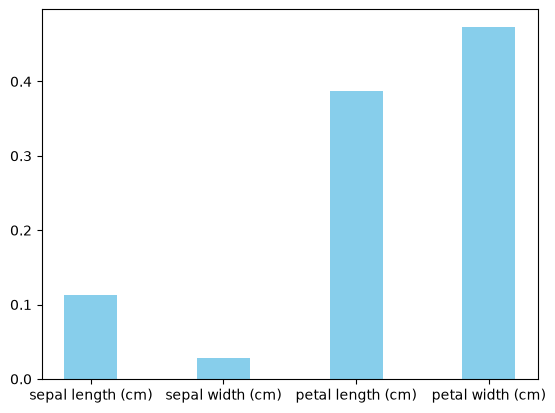

In [36]:
fet = rf.feature_importances_
plt.bar(iris.feature_names, fet, width = 0.4, color = 'skyblue')

In [37]:
bc = datasets.load_breast_cancer()

In [38]:
x = bc.data
y = bc.target

In [39]:
np.shape(x)

(569, 30)

In [40]:
np.shape(y)

(569,)

In [41]:
np.unique(y)

array([0, 1])

In [42]:
len(bc.feature_names)

30

In [43]:
xtr, xte, ytr, yte = train_test_split(x, y, test_size = 0.2, random_state = 33550336, stratify = y)

In [44]:
print(np.shape(xtr))
print(np.shape(xte))
print(np.shape(ytr))
print(np.shape(yte))

(455, 30)
(114, 30)
(455,)
(114,)


In [45]:
from sklearn.metrics import accuracy_score

In [46]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=33550336)
rf.fit(xtr, ytr)
yp = rf.predict(xte)
accuracy = accuracy_score(yte, yp)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9649122807017544


In [47]:
from sklearn.ensemble import GradientBoostingClassifier

In [48]:
clf = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)
clf.fit(xtr, ytr)
predictions = clf.predict(xte)
print(f"Accuracy: {accuracy_score(yte, predictions):.4f}")

Accuracy: 0.9561


In [49]:
from xgboost import XGBClassifier

In [50]:
model = XGBClassifier(n_estimators = 100, max_depth = 3, learning_rate = 0.1, objective = 'binary:logistic')
model.fit(xtr, ytr)
preds = model.predict(xte)
prob = model.predict_proba(xte)

In [51]:
accuracy = accuracy_score(yte, preds)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 97.37%


In [52]:
iris = datasets.load_iris()

In [53]:
x = iris.data
y = iris.target

In [67]:
bc = datasets.load_breast_cancer()
x = bc.data
y = bc.target

In [68]:
xtr, xte, ytr, yte = train_test_split(x, y, test_size = 0.2, random_state = 33550336, stratify = y)

In [69]:
tmp = rng.choice(np.arange(120), size = 120, replace = True)
xboot = xtr[tmp]
yboot = ytr[tmp]
check = np.unique(tmp)
j = 0
oob = []
for i in range(120):
    if j >= len(check):
        break
    else:
        if i != check[j]:
            oob.append(i)
        else:
            j += 1

In [56]:
len(oob)

41

In [57]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
clf = DecisionTreeClassifier(max_depth = 3, criterion = 'gini', random_state = 33550336)
clf.fit(xboot, yboot)
predictions = clf.predict(xtr[oob])
print(f"Accuracy: {accuracy_score(ytr[oob], predictions):.2f}")

Accuracy: 0.98


In [59]:
oobs = []
preds = []
clfs = []
for i in range(100):
    tmp = rng.choice(np.arange(120), size = 120, replace = True)
    xboot = xtr[tmp]
    yboot = ytr[tmp]
    check = np.unique(tmp)
    j = 0
    oob = []
    for k in range(120):
        if j < len(check) and k != check[j]:
            oob.append(k)
        else:
            j += 1
    clf = DecisionTreeClassifier(max_depth = 3, criterion = 'gini', random_state = 33550336)
    clf.fit(xboot, yboot)
    clfs.append(clf)
    predictions = clf.predict(xtr[oob])
    oobs.append(oob)
    preds.append(predictions)

In [60]:
mt = [[] for _ in range(120)]
for i in range(100):
    for k in range(len(oobs[i])):
        obs = oobs[i][k]
        prods = preds[i][k]
        mt[obs].append(prods)

In [61]:
fp = []
for check in mt:
    fp.append(makeleaf(check))
print(f"accuracy: {accuracy_score(ytr, fp):.2f}" )

accuracy: 0.93


In [62]:
sm = []
for tree in clfs:
    sm.append(tree.predict(xte))
fps = []
for i in range(30):
    tmp = []
    for j in range(100):
        tmp.append(sm[j][i])
    fps.append(makeleaf(tmp))
print(f"accuracy: {accuracy_score(yte, fps):.2f}")

accuracy: 0.90


In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

In [71]:
rf = RandomForestClassifier(random_state = 33550336)
pg = {"n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20], 
    "min_samples_split":[2, 5, 10],}
gsearch = GridSearchCV(estimator = rf, param_grid = pg, cv = 5, scoring = "roc_auc")
bm = gsearch.fit(xtr, ytr)
tp = bm.predict_proba(xte)[:, 1]
ta = roc_auc_score(yte, tp)
print(f"Test set roc auc: {ta:.4f}")

Test set roc auc: 0.9894


In [72]:
rf = GradientBoostingClassifier(random_state = 33550336)
pg = {"n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20], 
    "min_samples_split":[2, 5, 10],}
gsearch = GridSearchCV(estimator = rf, param_grid = pg, cv = 5, scoring = "roc_auc")
bm = gsearch.fit(xtr, ytr)
tp = bm.predict_proba(xte)[:, 1]
ta = roc_auc_score(yte, tp)
print(f"Test set roc auc: {ta:.4f}")

Test set roc auc: 0.9897


In [79]:
rf = XGBClassifier(objective = "binary:logistic", random_state = 33550336)
pg = {"n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20], 
    "learning_rate":[0.01, 0.1, 0.2],}
gsearch = GridSearchCV(estimator = rf, param_grid = pg, cv = 5, scoring = "roc_auc")
bm = gsearch.fit(xtr, ytr)
tp = bm.predict_proba(xte)[:, 1]
ta = roc_auc_score(yte, tp)
print(f"Test set roc auc: {ta:.4f}")

Test set roc auc: 0.9897


In [80]:
rf = RandomForestClassifier(random_state = 33550336)
pg = {"n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20], 
    "min_samples_split":[2, 5, 10],}
gsearch = GridSearchCV(estimator = rf, param_grid = pg, cv = 5, scoring = "roc_auc")
bm = gsearch.fit(xtr, ytr)
brf = gsearch.best_estimator_
importances = brf.feature_importances_

In [88]:
indices = np.argsort(importances)
indices = indices[::-1]
indices

array([22, 20, 27, 23,  7,  3,  0, 13, 26,  2,  6, 21, 24, 10,  5,  1, 25,
       28, 12, 29, 16,  4, 14, 19, 15, 11, 17, 18,  9,  8])

In [94]:
for i in range(5):
    print(bc.feature_names[indices[i]])
    print(importances[indices[i]])

worst perimeter
0.14201075208483627
worst radius
0.13613517983545967
worst concave points
0.11880796042610756
worst area
0.11860647590252084
mean concave points
0.10009028793175431


<BarContainer object of 5 artists>

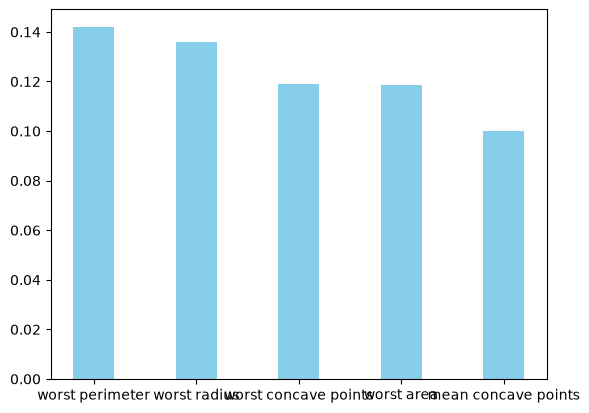

In [97]:
plt.bar(bc.feature_names[indices[:5]], importances[indices[:5]], color = 'skyblue', width = 0.4)